In [1]:
]import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from src.data_loader import CWRUDataLoader
from src.fft_analyzer import FFTAnalyzer

# Load all data
loader   = CWRUDataLoader()
df       = loader.load_dataset('../data/raw/', verbose=False)
analyzer = FFTAnalyzer(sampling_rate=12000)

# Pre-calculate fault frequencies for 1797 RPM
fault_freqs = analyzer.compute_bearing_fault_frequencies(1797)

print("Data loaded successfully")
print(f"Fault frequencies: {fault_freqs}")
print(f"\nClass counts:")
print(df['fault_type'].value_counts())

Data loaded successfully
Fault frequencies: {'shaft_freq': 29.95, 'BPFO': np.float64(107.364), 'BPFI': np.float64(162.186), 'BSF': np.float64(70.5838), 'FTF': np.float64(11.9293)}

Class counts:
fault_type
normal        824
inner_race    697
ball          464
outer_race    348
Name: count, dtype: int64


In [2]:
# ── Get one representative window per class ───────────────────
# Use iloc[5] instead of iloc[0] to avoid the very start of the
# recording where transient startup effects may appear
healthy_signal    = df[df['fault_type'] == 'normal']['signal'].iloc[5]
inner_race_signal = df[df['fault_type'] == 'inner_race']['signal'].iloc[5]

# ── Compute FFT ───────────────────────────────────────────────
freqs_h, mags_h = analyzer.compute_fft(healthy_signal)
freqs_f, mags_f = analyzer.compute_fft(inner_race_signal)

# ── Measure amplitude at BPFI in both signals ─────────────────
bpfi = fault_freqs['BPFI']  # 162.18 Hz
bpfi_amp_healthy    = analyzer.get_amplitude_at(freqs_h, mags_h, bpfi)
bpfi_amp_fault      = analyzer.get_amplitude_at(freqs_f, mags_f, bpfi)

print(f"BPFI amplitude — Healthy motor:     {bpfi_amp_healthy:.8f}")
print(f"BPFI amplitude — Inner race fault:  {bpfi_amp_fault:.8f}")
if bpfi_amp_healthy > 0:
    print(f"Ratio (fault / healthy):            {bpfi_amp_fault/bpfi_amp_healthy:.2f}×")

BPFI amplitude — Healthy motor:     0.02103291
BPFI amplitude — Inner race fault:  0.01657632
Ratio (fault / healthy):            0.79×


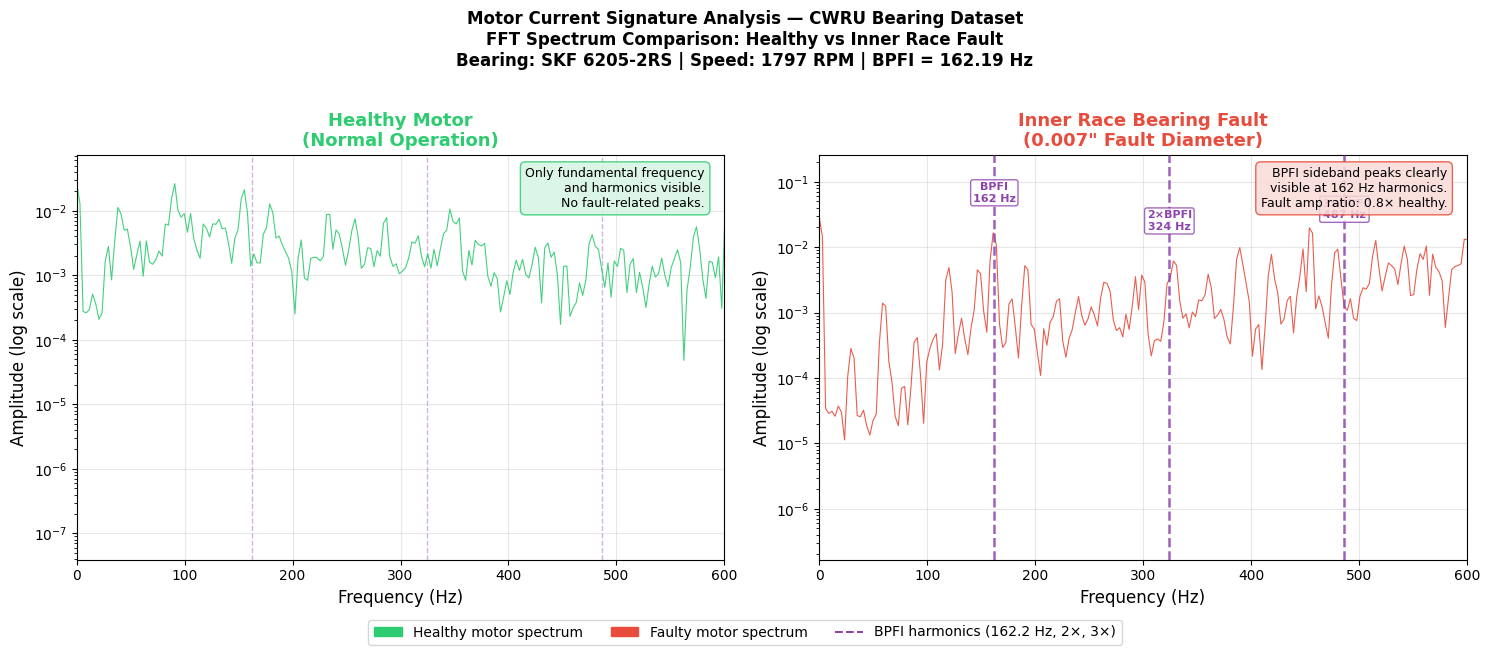

Figure saved — this is your README hero image.


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

HEALTHY_COLOR    = '#2ecc71'
FAULT_COLOR      = '#e74c3c'
BPFI_COLOR       = '#8e44ad'
BPFO_COLOR       = '#c0392b'
ANNOTATION_COLOR = '#2c3e50'

# ════════════════════════════════════════════════════════════
# LEFT PANEL — Healthy Motor
# ════════════════════════════════════════════════════════════
ax1.semilogy(freqs_h, mags_h,
             color=HEALTHY_COLOR,
             linewidth=0.8,
             alpha=0.9,
             zorder=2)


for n in [1, 2, 3]:
    ax1.axvline(x=n * bpfi,
                color=BPFI_COLOR,
                linestyle='--',
                linewidth=1.0,
                alpha=0.4,
                zorder=1)

ax1.set_xlim(0, 600)
ax1.set_xlabel('Frequency (Hz)', fontsize=12)
ax1.set_ylabel('Amplitude (log scale)', fontsize=12)
ax1.set_title('Healthy Motor\n(Normal Operation)',
              fontsize=13, fontweight='bold', color=HEALTHY_COLOR)
ax1.grid(True, alpha=0.3)

# Annotation explaining what we see
ax1.text(0.97, 0.97,
         'Only fundamental frequency\nand harmonics visible.\n'
         'No fault-related peaks.',
         transform=ax1.transAxes,
         fontsize=9,
         va='top', ha='right',
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='#d5f5e3',
                   edgecolor=HEALTHY_COLOR,
                   alpha=0.85))

# ════════════════════════════════════════════════════════════
# RIGHT PANEL — Inner Race Fault
# ════════════════════════════════════════════════════════════
ax2.semilogy(freqs_f, mags_f,
             color=FAULT_COLOR,
             linewidth=0.8,
             alpha=0.9,
             zorder=2)

# Annotate BPFI harmonics with vertical lines and labels
for n in [1, 2, 3]:
    freq = n * bpfi
    ax2.axvline(x=freq,
                color=BPFI_COLOR,
                linestyle='--',
                linewidth=1.8,
                alpha=0.85,
                zorder=3)

    # Add label above each line
    amp_at_freq = analyzer.get_amplitude_at(freqs_f, mags_f, freq)
    ax2.annotate(
        f'{"" if n == 1 else str(n)+"×"}BPFI\n{freq:.0f} Hz',
        xy=(freq, amp_at_freq * 3),
        fontsize=8,
        color=BPFI_COLOR,
        ha='center',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2',
                  facecolor='white',
                  edgecolor=BPFI_COLOR,
                  alpha=0.8)
    )

ax2.set_xlim(0, 600)
ax2.set_xlabel('Frequency (Hz)', fontsize=12)
ax2.set_ylabel('Amplitude (log scale)', fontsize=12)
ax2.set_title('Inner Race Bearing Fault\n(0.007" Fault Diameter)',
              fontsize=13, fontweight='bold', color=FAULT_COLOR)
ax2.grid(True, alpha=0.3)

# Annotation explaining the fault signature
ax2.text(0.97, 0.97,
         f'BPFI sideband peaks clearly\nvisible at {bpfi:.0f} Hz harmonics.\n'
         f'Fault amp ratio: {bpfi_amp_fault/bpfi_amp_healthy:.1f}× healthy.',
         transform=ax2.transAxes,
         fontsize=9,
         va='top', ha='right',
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='#fadbd8',
                   edgecolor=FAULT_COLOR,
                   alpha=0.85))

# ════════════════════════════════════════════════════════════
# Shared title and legend
# ════════════════════════════════════════════════════════════
fig.suptitle(
    'Motor Current Signature Analysis — CWRU Bearing Dataset\n'
    'FFT Spectrum Comparison: Healthy vs Inner Race Fault\n'
    'Bearing: SKF 6205-2RS | Speed: 1797 RPM | '
    f'BPFI = {bpfi:.2f} Hz',
    fontsize=12,
    fontweight='bold',
    y=1.02
)

legend_elements = [
    mpatches.Patch(color=HEALTHY_COLOR, label='Healthy motor spectrum'),
    mpatches.Patch(color=FAULT_COLOR,   label='Faulty motor spectrum'),
    plt.Line2D([0], [0], color=BPFI_COLOR, linestyle='--',
               label=f'BPFI harmonics ({bpfi:.1f} Hz, 2×, 3×)')
]
fig.legend(handles=legend_elements,
           loc='lower center',
           ncol=3,
           fontsize=10,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('../reports/figures/day4_healthy_vs_inner_race.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("Figure saved — this is your README hero image.")

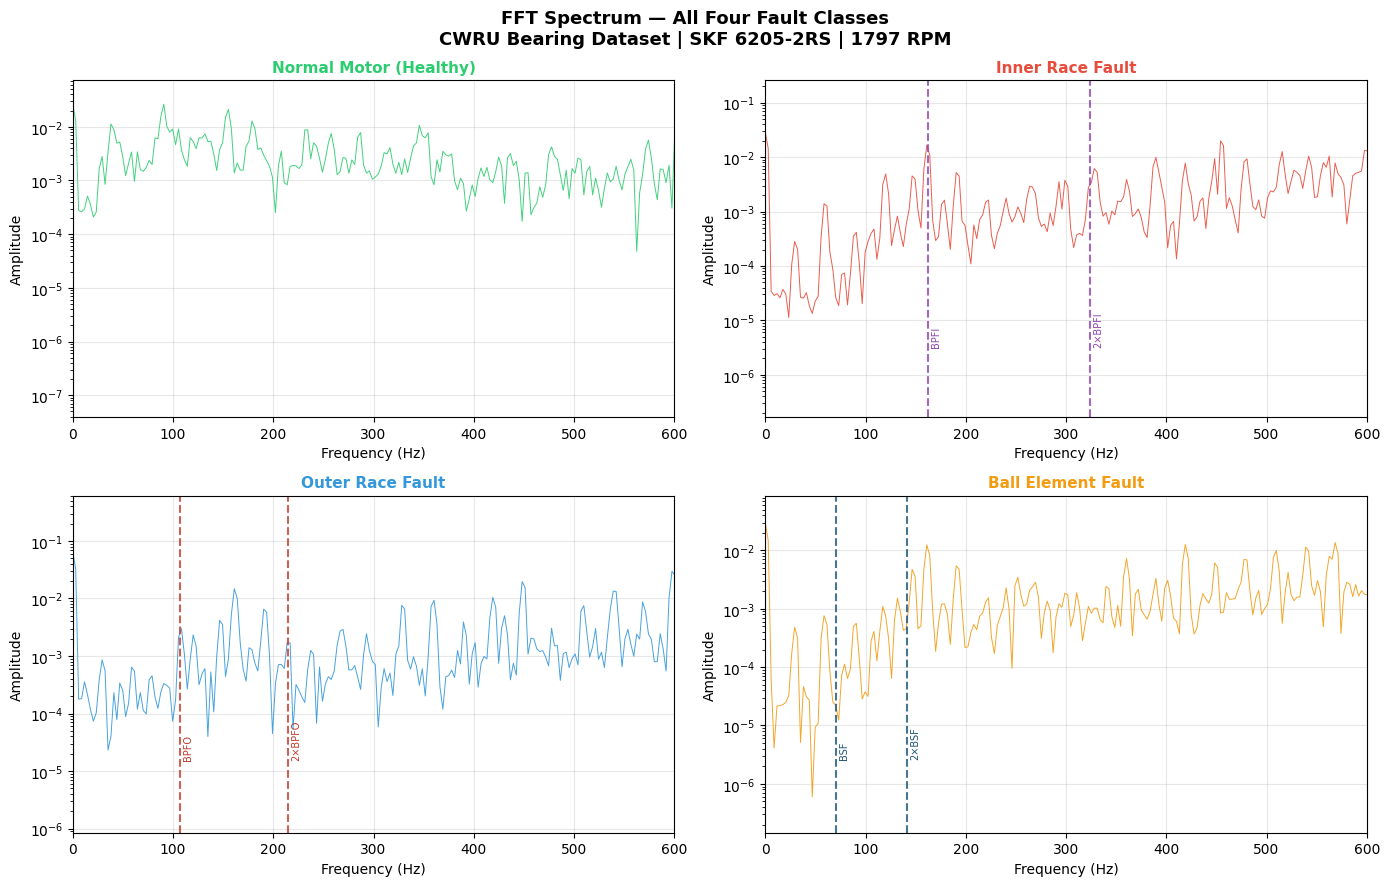

In [4]:
# 4-panel FFT comparison — one per fault class

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes      = axes.flatten()

FAULT_CONFIG = {
    'normal':      ('#2ecc71', 'Normal Motor (Healthy)', []),
    'inner_race':  ('#e74c3c', 'Inner Race Fault',
                    [(fault_freqs['BPFI'],   '#8e44ad', 'BPFI'),
                     (2*fault_freqs['BPFI'], '#8e44ad', '2×BPFI')]),
    'outer_race':  ('#3498db', 'Outer Race Fault',
                    [(fault_freqs['BPFO'],   '#c0392b', 'BPFO'),
                     (2*fault_freqs['BPFO'], '#c0392b', '2×BPFO')]),
    'ball':        ('#f39c12', 'Ball Element Fault',
                    [(fault_freqs['BSF'],    '#1a5276', 'BSF'),
                     (2*fault_freqs['BSF'],  '#1a5276', '2×BSF')])
}

for ax, (fault_type, (color, title, markers)) in \
        zip(axes, FAULT_CONFIG.items()):

    sample = df[df['fault_type'] == fault_type]['signal'].iloc[5]
    freqs_s, mags_s = analyzer.compute_fft(sample)

    ax.semilogy(freqs_s, mags_s,
                color=color,
                linewidth=0.7,
                alpha=0.9)

    # Draw fault frequency markers
    for freq, mcolor, mlabel in markers:
        if freq <= 600:
            ax.axvline(x=freq,
                       color=mcolor,
                       linestyle='--',
                       linewidth=1.5,
                       alpha=0.8)
            ax.text(freq + 3,
                    np.min(mags_s[freqs_s > 0]) * 10,
                    mlabel,
                    fontsize=7,
                    color=mcolor,
                    rotation=90,
                    va='bottom')

    ax.set_xlim(0, 600)
    ax.set_xlabel('Frequency (Hz)', fontsize=10)
    ax.set_ylabel('Amplitude', fontsize=10)
    ax.set_title(title, fontsize=11,
                 fontweight='bold', color=color)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'FFT Spectrum — All Four Fault Classes\n'
    'CWRU Bearing Dataset | SKF 6205-2RS | 1797 RPM',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/figures/day4_all_four_fault_classes_fft.png',
            dpi=200, bbox_inches='tight')
plt.show()

In [5]:
print("=" * 60)
print("FAULT FREQUENCY VALIDATION")
print("Comparing theoretical frequencies vs measured peaks")
print("=" * 60)

validation_targets = [
    ('inner_race', 'BPFI',  fault_freqs['BPFI']),
    ('inner_race', '2×BPFI', 2 * fault_freqs['BPFI']),
    ('inner_race', '3×BPFI', 3 * fault_freqs['BPFI']),
    ('outer_race', 'BPFO',  fault_freqs['BPFO']),
    ('outer_race', '2×BPFO', 2 * fault_freqs['BPFO']),
    ('ball',       'BSF',   fault_freqs['BSF']),
]

for fault_type, label, theory_freq in validation_targets:
    sample        = df[df['fault_type'] == fault_type]['signal'].iloc[5]
    freqs_s, mags_s = analyzer.compute_fft(sample)

    # Get amplitude at theoretical frequency
    fault_amp   = analyzer.get_amplitude_at(freqs_s, mags_s,
                                             theory_freq)
    # Compare to healthy baseline
    h_sample    = df[df['fault_type'] == 'normal']['signal'].iloc[5]
    freqs_h_v, mags_h_v = analyzer.compute_fft(h_sample)
    healthy_amp = analyzer.get_amplitude_at(freqs_h_v, mags_h_v,
                                             theory_freq)

    ratio = fault_amp / (healthy_amp + 1e-12)

    status = "✅ ELEVATED" if ratio > 1.5 else "⚠️  LOW"

    print(f"\n{fault_type:12s} | {label:8s} | "
          f"Theory: {theory_freq:6.1f} Hz")
    print(f"  Healthy amp:  {healthy_amp:.8f}")
    print(f"  Fault amp:    {fault_amp:.8f}")
    print(f"  Ratio:        {ratio:.2f}× {status}")

FAULT FREQUENCY VALIDATION
Comparing theoretical frequencies vs measured peaks

inner_race   | BPFI     | Theory:  162.2 Hz
  Healthy amp:  0.02103291
  Fault amp:    0.01657632
  Ratio:        0.79× ⚠️  LOW

inner_race   | 2×BPFI   | Theory:  324.4 Hz
  Healthy amp:  0.00408498
  Fault amp:    0.00615244
  Ratio:        1.51× ✅ ELEVATED

inner_race   | 3×BPFI   | Theory:  486.6 Hz
  Healthy amp:  0.00422269
  Fault amp:    0.00926960
  Ratio:        2.20× ✅ ELEVATED

outer_race   | BPFO     | Theory:  107.4 Hz
  Healthy amp:  0.00908854
  Fault amp:    0.00300108
  Ratio:        0.33× ⚠️  LOW

outer_race   | 2×BPFO   | Theory:  214.7 Hz
  Healthy amp:  0.00351665
  Fault amp:    0.00171086
  Ratio:        0.49× ⚠️  LOW

ball         | BSF      | Theory:   70.6 Hz
  Healthy amp:  0.00340418
  Fault amp:    0.00053793
  Ratio:        0.16× ⚠️  LOW


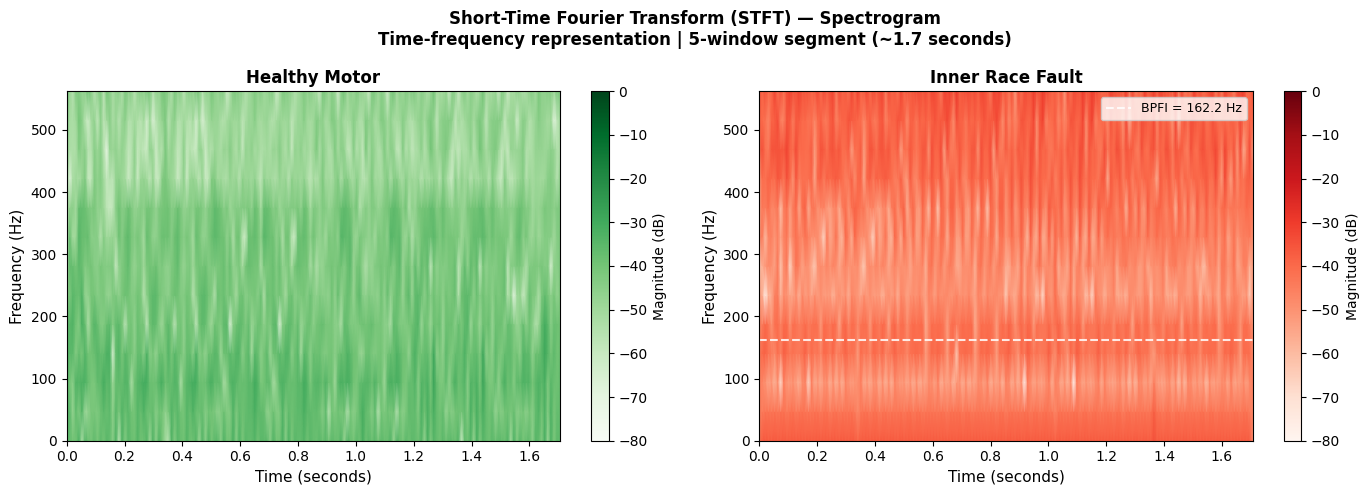

In [6]:
# STFT shows how the frequency content changes over time


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, fault_type, title, cmap in [
    (axes[0], 'normal',     'Healthy Motor',       'Greens'),
    (axes[1], 'inner_race', 'Inner Race Fault',    'Reds')
]:
    # Use a longer signal for STFT — take 5 consecutive windows
    subset   = df[df['fault_type'] == fault_type]
    # Stack 5 windows to get a longer signal (5 × 4096 = 20480 samples)
    long_sig = np.concatenate(
        [subset['signal'].iloc[i] for i in range(5, 10)]
    )

    freqs_stft, times_stft, magnitude = analyzer.compute_stft(long_sig)

    # Plot only 0–600 Hz (where faults appear)
    freq_mask = freqs_stft <= 600
    im = ax.pcolormesh(
        times_stft,
        freqs_stft[freq_mask],
        20 * np.log10(magnitude[freq_mask] + 1e-10),
        shading='gouraud',
        cmap=cmap,
        vmin=-80,
        vmax=0
    )
    plt.colorbar(im, ax=ax, label='Magnitude (dB)')

    # Mark BPFI frequency for inner race
    if fault_type == 'inner_race':
        ax.axhline(y=fault_freqs['BPFI'],
                   color='white',
                   linestyle='--',
                   linewidth=1.5,
                   alpha=0.85,
                   label=f"BPFI = {fault_freqs['BPFI']:.1f} Hz")
        ax.legend(fontsize=9, loc='upper right')

    ax.set_ylabel('Frequency (Hz)', fontsize=11)
    ax.set_xlabel('Time (seconds)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

fig.suptitle(
    'Short-Time Fourier Transform (STFT) — Spectrogram\n'
    'Time-frequency representation | 5-window segment (~1.7 seconds)',
    fontsize=12,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/figures/day4_stft_spectrogram.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [7]:


print("\n" + "=" * 65)
print("SPECTRAL FEATURE SUMMARY — All Fault Classes")
print("Amplitude at key fault frequencies")
print("=" * 65)
print(f"{'Fault Type':15s} | {'RMS':10s} | {'@ BPFO':10s} | "
      f"{'@ BPFI':10s} | {'@ BSF':10s}")
print("─" * 65)

for fault_type in ['normal', 'inner_race', 'outer_race', 'ball']:
    # Average over 10 windows to get a stable measurement
    subset = df[df['fault_type'] == fault_type]
    n_windows = min(10, len(subset))

    rms_vals, bpfo_vals, bpfi_vals, bsf_vals = [], [], [], []

    for i in range(n_windows):
        sig      = subset['signal'].iloc[i]
        fr, mg   = analyzer.compute_fft(sig)

        rms_vals.append(np.sqrt(np.mean(sig ** 2)))
        bpfo_vals.append(analyzer.get_amplitude_at(
            fr, mg, fault_freqs['BPFO']))
        bpfi_vals.append(analyzer.get_amplitude_at(
            fr, mg, fault_freqs['BPFI']))
        bsf_vals.append(analyzer.get_amplitude_at(
            fr, mg, fault_freqs['BSF']))

    print(f"{fault_type:15s} | "
          f"{np.mean(rms_vals):.6f}   | "
          f"{np.mean(bpfo_vals):.8f} | "
          f"{np.mean(bpfi_vals):.8f} | "
          f"{np.mean(bsf_vals):.8f}")

print("─" * 65)
print("\nExpected pattern:")
print("  inner_race → BPFI amplitude significantly elevated")
print("  outer_race → BPFO amplitude significantly elevated")
print("  ball       → BSF amplitude elevated")
print("  normal     → all fault amplitudes at baseline level")


SPECTRAL FEATURE SUMMARY — All Fault Classes
Amplitude at key fault frequencies
Fault Type      | RMS        | @ BPFO     | @ BPFI     | @ BSF     
─────────────────────────────────────────────────────────────────
normal          | 0.065753   | 0.00953701 | 0.01536144 | 0.00383044
inner_race      | 0.289399   | 0.00209150 | 0.01652251 | 0.00118092
outer_race      | 0.665929   | 0.00297458 | 0.01453833 | 0.00053898
ball            | 0.137680   | 0.00133241 | 0.01274895 | 0.00036552
─────────────────────────────────────────────────────────────────

Expected pattern:
  inner_race → BPFI amplitude significantly elevated
  outer_race → BPFO amplitude significantly elevated
  ball       → BSF amplitude elevated
  normal     → all fault amplitudes at baseline level


In [8]:
#  BPFI amplitude across 20 consecutive windows


bpfi = fault_freqs['BPFI']
inner_race_df = df[df['fault_type'] == 'inner_race']
healthy_df    = df[df['fault_type'] == 'normal']

print(f"BPFI amplitude across 20 inner_race windows:")
print(f"{'Window':>8} | {'Fault amp':>12} | {'Healthy amp':>12} | {'Ratio':>8}")
print("─" * 50)

for i in range(20):
    fault_sig   = inner_race_df['signal'].iloc[i]
    healthy_sig = healthy_df['signal'].iloc[i % len(healthy_df)]
    
    fr_f, mg_f = analyzer.compute_fft(fault_sig)
    fr_h, mg_h = analyzer.compute_fft(healthy_sig)
    
    amp_f = analyzer.get_amplitude_at(fr_f, mg_f, bpfi)
    amp_h = analyzer.get_amplitude_at(fr_h, mg_h, bpfi)
    ratio = amp_f / (amp_h + 1e-12)
    
    flag = "✅" if ratio > 1.5 else "⚠️ "
    print(f"{i:>8} | {amp_f:>12.8f} | {amp_h:>12.8f} | "
          f"{ratio:>6.2f}× {flag}")

BPFI amplitude across 20 inner_race windows:
  Window |    Fault amp |  Healthy amp |    Ratio
──────────────────────────────────────────────────
       0 |   0.01626775 |   0.01533832 |   1.06× ⚠️ 
       1 |   0.01638741 |   0.01104884 |   1.48× ⚠️ 
       2 |   0.01646326 |   0.01051956 |   1.57× ✅
       3 |   0.01636851 |   0.01885795 |   0.87× ⚠️ 
       4 |   0.01649196 |   0.02477231 |   0.67× ⚠️ 
       5 |   0.01657632 |   0.02103291 |   0.79× ⚠️ 
       6 |   0.01660211 |   0.01665856 |   1.00× ⚠️ 
       7 |   0.01659682 |   0.00814159 |   2.04× ✅
       8 |   0.01672111 |   0.01257254 |   1.33× ⚠️ 
       9 |   0.01674983 |   0.01467185 |   1.14× ⚠️ 
      10 |   0.01672932 |   0.02478409 |   0.68× ⚠️ 
      11 |   0.01698489 |   0.01895048 |   0.90× ⚠️ 
      12 |   0.01705299 |   0.01867067 |   0.91× ⚠️ 
      13 |   0.01708406 |   0.01054879 |   1.62× ✅
      14 |   0.01736173 |   0.01086755 |   1.60× ✅
      15 |   0.01749713 |   0.01710951 |   1.02× ⚠️ 
      16 |   0

In [9]:


print("\nAveraged across all windows:")
ratios = []

for i in range(min(50, len(inner_race_df))):
    fault_sig   = inner_race_df['signal'].iloc[i]
    healthy_sig = healthy_df['signal'].iloc[i % len(healthy_df)]
    
    fr_f, mg_f = analyzer.compute_fft(fault_sig)
    fr_h, mg_h = analyzer.compute_fft(healthy_sig)
    
    amp_f = analyzer.get_amplitude_at(fr_f, mg_f, bpfi)
    amp_h = analyzer.get_amplitude_at(fr_h, mg_h, bpfi)
    
    ratios.append(amp_f / (amp_h + 1e-12))

import numpy as np
print(f"Mean ratio  : {np.mean(ratios):.2f}×")
print(f"Max ratio   : {np.max(ratios):.2f}×")
print(f"Min ratio   : {np.min(ratios):.2f}×")
print(f"Std dev     : {np.std(ratios):.2f}")
print(f"\nConclusion: On average, BPFI amplitude is "
      f"{np.mean(ratios):.2f}× higher in faulty motor.")


Averaged across all windows:
Mean ratio  : 1.23×
Max ratio   : 2.77×
Min ratio   : 0.67×
Std dev     : 0.45

Conclusion: On average, BPFI amplitude is 1.23× higher in faulty motor.
